In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
df1 = pd.read_csv("Sales/Sales_January_2019.csv")
df1["month"]="Jan"
df2 = pd.read_csv("Sales/Sales_February_2019.csv")
df2["month"]="feb"
df3 = pd.read_csv("Sales/Sales_March_2019.csv")
df3["month"]="mar"
df4 = pd.read_csv("Sales/Sales_April_2019.csv")
df4["month"]="apr"
df5 = pd.read_csv("Sales/Sales_May_2019.csv")
df5["month"]="may"
df6 = pd.read_csv("Sales/Sales_June_2019.csv")
df6["month"]="june"
df7 = pd.read_csv("Sales/Sales_July_2019.csv")
df7["month"]="july"
df8 = pd.read_csv("Sales/Sales_August_2019.csv")
df8["month"]="aug"
df9 = pd.read_csv("Sales/Sales_September_2019.csv")
df9["month"]="sep"
df10 = pd.read_csv("Sales/Sales_October_2019.csv")
df10["month"]="oct"
df11 = pd.read_csv("Sales/Sales_November_2019.csv")
df11["month"]="nov"
df12 = pd.read_csv("Sales/Sales_December_2019.csv")
df12["month"]="dec"

In [4]:
list=[df1 ,df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12]

In [54]:
df=pd.concat(list,  ignore_index=True)


In [ ]:
#Exploring data
df.duplicated().sum()
df.nunique()
df.isnull().sum()

array(['iPhone', 'Lightning Charging Cable', 'Wired Headphones',
       '27in FHD Monitor', 'AAA Batteries (4-pack)',
       '27in 4K Gaming Monitor', 'USB-C Charging Cable',
       'Bose SoundSport Headphones', 'Apple Airpods Headphones',
       'Macbook Pro Laptop', 'Flatscreen TV', 'Vareebadd Phone',
       'AA Batteries (4-pack)', 'Google Phone', '20in Monitor',
       '34in Ultrawide Monitor', 'ThinkPad Laptop', 'LG Dryer',
       'LG Washing Machine', nan, 'Product'], dtype=object)

In [83]:
#data cleaning
#dropping duplicates and empty rows
df=df.drop_duplicates()
df=df.dropna()

#renaming columns for more practicality
df=df.rename(columns={"Product":"product","Quantity Ordered":"quantity","Price Each":"price","Order Date":"date","Purchase Address":"address"})

#removing the nan product
df = df[df['product'] != 'nan']

#Fixing month casing
df['month']=df['month'].str.title()

#fixing quantiy 
df = df[df['quantity'] != 'Quantity Ordered']
df['quantity'] = df['quantity'].astype(int)

#fixing price column
df['price']=df["price"].astype(float)

#extracting city from address 
df['city'] = df['address'].str.split(',').str[1].str.strip()

#converting to date
df['date']=pd.to_datetime(df['date'])
df['hour']=df['date'].dt.hour

#adding revenue column
df["revenue"]=df['price']*df['quantity']

In [141]:
#product sold most
most_sold=(df.groupby("product")["quantity"].sum()).idxmax()
print(f"Most sold product: {most_sold}")
#highest month sales
highest_month=(df.groupby("month")["quantity"].sum()).idxmax()
print(f"Month with highest sales: {highest_month}")
#most buying city
most_city=(df.groupby("city")['revenue'].sum()).idxmax()
print(f"Most buying city: {most_city}")
#total gross revenue
total_rev=df['revenue'].sum()
print(f"Total gross revenue: {total_rev} USD ")
#busiest hours
busiest=(df.groupby("hour")["quantity"].count()).idxmax()
print(f"Busiest hour is: {busiest}")
#most revenue product
most_rev=(df.groupby('product')['revenue'].sum()).idxmax()
print(f"product with most revenue: {most_rev}")
#average order value
avg=round(df["revenue"].mean())
print(f"Average order value: {avg} USD")
#month with highest revenue
highes_rev=(df.groupby('month')['revenue'].sum()).idxmax()
print(f"Month with highest revenue: {highes_rev}")


Most sold product: AAA Batteries (4-pack)
Month with highest sales: Dec
Most buying city: San Francisco
Total gross revenue: 34465537.94 USD 
Busiest hour is: 19
product with most revenue: Macbook Pro Laptop
Average order value: 186 USD
Month with highest revenue: Dec


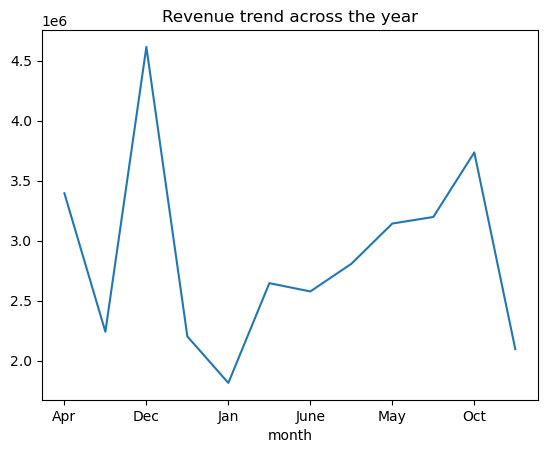

In [ ]:
#data visualization
#Revenue trend across 12 months
rev=df.groupby('month')['revenue'].sum()
rev.plot(kind='line',title="Revenue trend across the year")
plt.show()


<Axes: title={'center': 'Top 5 products by revenue'}, xlabel='product'>

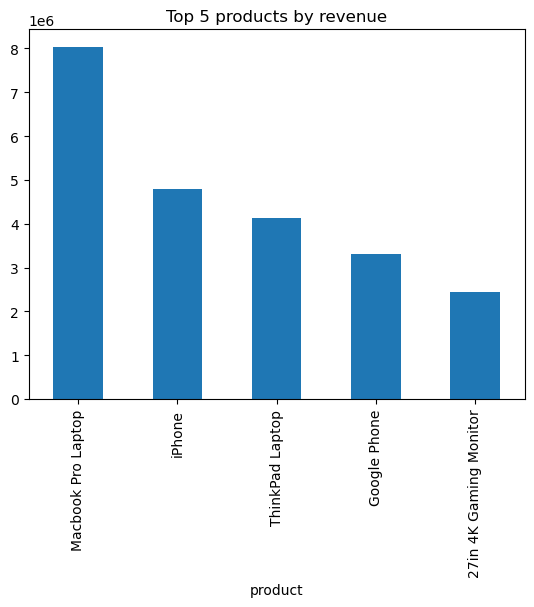

In [ ]:
#Top 5 products by revenue
topproducts=df.groupby("product")['revenue'].sum()
topproducts=topproducts.nlargest(5)
topproducts.plot(kind='bar',title="Top 5 products by revenue")
plt.show()

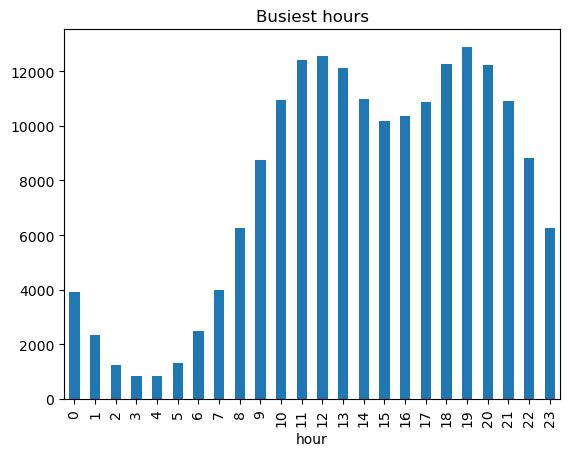

In [138]:
#Orders by hour
busiest_hours=df.groupby('hour')['quantity'].count()
busiest_hours.plot(kind='bar',title='Busiest hours')
plt.show()